In [119]:
%pip install torch pandas numpy scikit-learn tqdm

In [120]:
!git clone https://github.com/imets01/synthetic_network_data_gen.git

Cloning into 'synthetic_network_data_gen'...
remote: Enumerating objects: 508, done.
remote: Counting objects: 100% (508/508), done.
remote: Compressing objects: 100% (251/251), done.
remote: Total 508 (delta 290), reused 455 (delta 251), pack-reused 0 (from 0)
Receiving objects: 100% (508/508), 3.89 MiB | 17.03 MiB/s, done.
Resolving deltas: 100% (290/290), done.


In [121]:
%cd synthetic_network_data_gen
!git fetch
!git checkout anna

/content/synthetic_network_data_gen/synthetic_network_data_gen/synthetic_network_data_gen/synthetic_network_data_gen
Branch 'anna' set up to track remote branch 'anna' from 'origin'.
Switched to a new branch 'anna'


In [122]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

In [123]:
class QuicSequenceDataset(Dataset):
    def __init__(self, high_level_csv, low_level_dir):
        self.high_level_df = pd.read_csv(high_level_csv)
        self.high_level_df = self.high_level_df.head(20)
        self.low_level_dir = low_level_dir

        not_to_use_for_training = ['initial_ip_client', 'initial_ip_server', 'initial_port_client', 'initial_port_server','time_first', 'time_last']
        self.condition_features = self.high_level_df.drop(not_to_use_for_training, axis=1)
        categorical_cols = self.condition_features.select_dtypes(include=['object', 'category']).columns

        numeric_cols = self.condition_features.select_dtypes(include=np.number).drop('file_id', axis=1).columns
        self.condition_features = pd.get_dummies(self.condition_features, columns=categorical_cols, prefix=categorical_cols)
        self.flow_ids = self.high_level_df['file_id']

        self.condition_scaler = MinMaxScaler()
        self.sequence_scaler = MinMaxScaler()

        self.scaled_conditions = self.condition_scaler.fit_transform(self.condition_features)

        all_sequences = []
        self.sequence_columns = None

        for flow_id in self.flow_ids:
            file_path = os.path.join(self.low_level_dir, f"quiche_capture_{flow_id}.csv")
            df = pd.read_csv(file_path)

            if self.sequence_columns is None:
                    self.sequence_columns = df.columns.tolist()
            all_sequences.append(df.values)

        full_sequence_data = np.concatenate(all_sequences, axis=0)
        self.sequence_scaler.fit(full_sequence_data)

    def __len__(self):
        return len(self.high_level_df)

    def __getitem__(self, idx):
        flow_id = self.flow_ids[idx]
        file_path = os.path.join(self.low_level_dir, f"quiche_capture_{flow_id}.csv")

        sequence_df = pd.read_csv(file_path)
        scaled_sequence = self.sequence_scaler.transform(sequence_df.values)

        scaled_condition = self.scaled_conditions[idx]

        return {
            'sequence': torch.FloatTensor(scaled_sequence),
            'condition': torch.FloatTensor(scaled_condition)
        }

In [124]:
def collate_fn(batch):
    sequences = [item['sequence'] for item in batch]
    conditions = torch.stack([item['condition'] for item in batch])
    padded_sequences = nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=0.0)
    return {'sequence': padded_sequences, 'condition': conditions}

In [125]:
class Generator(nn.Module):
    def __init__(self, latent_dim, condition_dim, sequence_feature_dim, hidden_dim=64, num_layers=1):
        super().__init__()

        # CHANGED: Use LSTM instead of GRU
        self.rnn = nn.LSTM(input_size=sequence_feature_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)

        # We now need to generate an initial hidden state AND a cell state
        # It's cleaner to have two separate layers for this.
        self.fc_init_h = nn.Linear(latent_dim + condition_dim, hidden_dim * num_layers)
        self.fc_init_c = nn.Linear(latent_dim + condition_dim, hidden_dim * num_layers)

        self.fc_out = nn.Linear(hidden_dim, sequence_feature_dim)
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

    def forward(self, noise, condition, seq_len):
        batch_size = noise.shape[0]
        combined_input = torch.cat([noise, condition], dim=1)

        # CHANGED: Create initial hidden state (h0) and cell state (c0)
        # We need to reshape them to (num_layers, batch_size, hidden_dim)
        h0 = self.fc_init_h(combined_input).view(self.num_layers, batch_size, self.hidden_dim)
        c0 = self.fc_init_c(combined_input).view(self.num_layers, batch_size, self.hidden_dim)

        # The initial state for the LSTM is a tuple
        initial_state = (h0, c0)

        # The rest of the logic is the same, but we pass the tuple
        dummy_input = torch.zeros(batch_size, seq_len, self.rnn.input_size, device=noise.device)

        # The LSTM returns the output and a tuple of the final hidden/cell states
        rnn_out, _ = self.rnn(dummy_input, initial_state)

        output = torch.sigmoid(self.fc_out(rnn_out)) # Use sigmoid for [0, 1] range
        return output

class Discriminator(nn.Module):
    def __init__(self, condition_dim, sequence_feature_dim, hidden_dim=64, num_layers=1):
        super().__init__()

        self.rnn = nn.LSTM(input_size=sequence_feature_dim + condition_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)

        self.fc_out = nn.Linear(hidden_dim, 1)

    def forward(self, sequence, condition):
        seq_len = sequence.shape[1]
        condition_expanded = condition.unsqueeze(1).repeat(1, seq_len, 1)
        combined_input = torch.cat([sequence, condition_expanded], dim=2)

        # CHANGED: The LSTM returns output, (hn, cn)
        # We only need the final hidden state (hn) for our decision.
        # PyTorch handles the zero-initialization of states for us if we don't provide one.
        _, (hn, cn) = self.rnn(combined_input)

        # We use the final hidden state of the last layer for the classification
        # hn is shaped (num_layers, batch_size, hidden_dim), so we take the last layer's state
        out = self.fc_out(hn[-1])

        return out


In [126]:
def train_rgan(dataloader, generator, discriminator, g_optimizer, d_optimizer, loss_fn, device, epochs=100, latent_dim=10):
    for epoch in range(epochs):
        for i, batch in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")):
            real_sequences = batch['sequence'].to(device)
            conditions = batch['condition'].to(device)
            batch_size, seq_len, _ = real_sequences.shape

            # Train Discriminator
            d_optimizer.zero_grad()
            real_output = discriminator(real_sequences, conditions)
            loss_real = loss_fn(real_output, torch.ones_like(real_output))

            noise = torch.randn(batch_size, latent_dim, device=device)
            fake_sequences = generator(noise, conditions, seq_len)
            fake_output = discriminator(fake_sequences.detach(), conditions)
            loss_fake = loss_fn(fake_output, torch.zeros_like(fake_output))

            d_loss = (loss_real + loss_fake) / 2
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 1.0)
            d_optimizer.step()

            # Train Generator
            g_optimizer.zero_grad()
            gen_output = discriminator(fake_sequences, conditions)
            g_loss = loss_fn(gen_output, torch.ones_like(gen_output))
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)
            g_optimizer.step()

        print(f"Epoch [{epoch+1}/{epochs}], D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

In [127]:
DATA_DIR = "quic_data"
BATCH_SIZE = 64
LATENT_DIM = 20
HIDDEN_DIM = 256
EPOCHS = 2000
LR_G = 0.00005
LR_D = 0.000005

In [128]:
high_level_csv = '/content/synthetic_network_data_gen/high_level_features/quiche/quiche_all_extracted_high_level_features.csv'
low_level_dir = '/content/synthetic_network_data_gen/low_level_features/quiche'

In [129]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

dataset = QuicSequenceDataset(high_level_csv, low_level_dir)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)


Using device: cuda


In [130]:
# Get dimensions
condition_dim = dataset.scaled_conditions.shape[1]
sequence_feature_dim = dataset.sequence_scaler.n_features_in_

In [131]:
condition_dim, sequence_feature_dim

(46, 24)

In [132]:
# 3. Instantiate models
generator = Generator(LATENT_DIM, condition_dim, sequence_feature_dim, HIDDEN_DIM, 6).to(device)
discriminator = Discriminator(condition_dim, sequence_feature_dim, HIDDEN_DIM, 1).to(device)


In [133]:
# 4. Optimizers and Loss
g_optimizer = torch.optim.Adam(generator.parameters(), lr=LR_G, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=LR_D, betas=(0.5, 0.999))
loss_fn = nn.BCEWithLogitsLoss()

# 5. Train
train_rgan(dataloader, generator, discriminator, g_optimizer, d_optimizer, loss_fn, device, epochs=EPOCHS, latent_dim=LATENT_DIM)



Epoch 1/2000: 100%|██████████| 1/1 [00:00<00:00, 13.29it/s]


Epoch [1/2000], D Loss: 0.6917, G Loss: 0.6978


Epoch 2/2000: 100%|██████████| 1/1 [00:00<00:00, 18.57it/s]


Epoch [2/2000], D Loss: 0.6916, G Loss: 0.6979


Epoch 3/2000: 100%|██████████| 1/1 [00:00<00:00, 18.61it/s]


...

Epoch [1998/2000], D Loss: 0.6862, G Loss: 0.6915


Epoch 1999/2000: 100%|██████████| 1/1 [00:00<00:00, 14.25it/s]


Epoch [1999/2000], D Loss: 0.6865, G Loss: 0.6911


Epoch 2000/2000: 100%|██████████| 1/1 [00:00<00:00, 14.70it/s]

Epoch [2000/2000], D Loss: 0.6868, G Loss: 0.6905


In [134]:
def post_process_generated_data(df, binary_cols, integer_cols):
    processed_df = df.copy()

    for col in binary_cols:
        if col in processed_df.columns:
            # Round to the nearest integer (0 or 1) and clip to ensure it's in [0, 1]
            processed_df[col] = processed_df[col].clip(0, 1).round().astype(int)

    for col in integer_cols:
        if col in processed_df.columns:
            # Round to the nearest integer and clip at 0 to prevent negatives
            processed_df[col] = processed_df[col].clip(lower=0).round().astype(int)

    return processed_df

In [135]:
integer_cols = ['packet_length', 'count_initial', 'count_0rtt', 'count_handshake',
                'count_retry', 'count_vn', 'count_1rtt', 'count_ack', 'count_padding', 'count_connection_close',
                'count_path_challenge', 'count_path_response', 'count_new_connection_id',
                'count_retire_cid', 'count_crypto', 'count_handshake_done', 'http3_stream_count',
                'http3_fin_count', 'stream_length', 'stream_type_count']
binary_cols = ['packet_direction', 'header_form']

In [136]:
print("\n--- Generating a new sample ---")

generator.eval()
with torch.no_grad():
    sample_condition_scaled = dataset[0]['condition'].unsqueeze(0).to(device)
    noise = torch.randn(1, LATENT_DIM, device=device)
    desired_seq_len = 25

    generated_sequence_scaled = generator(noise, sample_condition_scaled, desired_seq_len)

    generated_sequence_scaled_cpu = generated_sequence_scaled.squeeze(0).cpu().numpy()
    generated_sequence_original_scale = dataset.sequence_scaler.inverse_transform(generated_sequence_scaled_cpu)

    print("Generated sequence shape:", generated_sequence_original_scale.shape)
    og_scale = pd.DataFrame(generated_sequence_original_scale, columns=dataset.sequence_columns)
    print("Sample of generated data (original scale):\n")
    display(og_scale)
    print("Sample of generated data (processed scale):\n")
    display(post_process_generated_data(og_scale, binary_cols=binary_cols, integer_cols=integer_cols))


--- Generating a new sample ---
Generated sequence shape: (25, 24)
Sample of generated data (original scale):



,frame_number,delta_time,packet_length,packet_direction,header_form,count_initial,count_0rtt,count_handshake,count_1rtt,count_retry,...,count_path_challenge,count_path_response,count_new_connection_id,count_retire_cid,count_crypto,count_handshake_done,http3_stream_count,http3_fin_count,stream_length,stream_type_count
0,13.676966,0.002012,708.495117,0.493240,0.437078,0.434155,0.411995,0.492789,0.562999,0.462123,...,0.477873,0.436091,0.428085,0.477845,0.871790,0.433416,0.481097,0.423403,49.303288,0.428999
1,14.118307,0.001813,662.115417,0.509423,0.349851,0.361856,0.334697,0.418397,0.608546,0.355673,...,0.421289,0.405811,0.352458,0.420873,0.691755,0.350265,0.442026,0.357303,43.647289,0.401210
2,14.607806,0.001492,595.696777,0.532155,0.240864,0.263311,0.224455,0.307053,0.676807,0.223406,...,0.343352,0.358090,0.250254,0.316230,0.453793,0.234584,0.387001,0.268519,34.265869,0.361391
3,14.844451,0.001052,518.579651,0.561546,0.135292,0.159422,0.115738,0.180575,0.761368,0.104961,...,0.251723,0.303607,0.146762,0.185883,0.227576,0.122638,0.314914,0.169964,22.870125,0.312211
4,14.266713,0.000623,465.134216,0.596016,0.069915,0.090040,0.050595,0.088582,0.833557,0.042055,...,0.176647,0.267155,0.079405,0.088603,0.097480,0.057663,0.240853,0.095396,13.536460,0.266838
5,12.530919,0.000345,466.833313,0.626163,0.043987,0.059749,0.024634,0.045557,0.872979,0.020035,...,0.137900,0.269252,0.050590,0.044269,0.048089,0.033027,0.178143,0.053040,7.880124,0.229759
6,10.391365,0.000212,515.558350,0.644768,0.037422,0.048813,0.015562,0.029457,0.888230,0.013166,...,0.125542,0.302869,0.041721,0.027832,0.031823,0.025521,0.123619,0.029787,4.689922,0.188401
7,8.848818,0.000151,571.184814,0.653119,0.037157,0.043489,0.012061,0.023525,0.896036,0.010730,...,0.122331,0.343481,0.039603,0.021235,0.025728,0.023444,0.081516,0.017460,2.904285,0.146390
8,7.995317,0.000117,609.408081,0.652012,0.037448,0.038831,0.010395,0.021129,0.902915,0.009607,...,0.119529,0.376850,0.038486,0.018021,0.022472,0.022618,0.056499,0.011247,1.918317,0.114607
9,7.562871,0.000095,631.371460,0.639938,0.036461,0.034173,0.009365,0.019901,0.908900,0.008948,...,0.114245,0.400506,0.036864,0.016073,0.020094,0.021735,0.043401,0.007812,1.342639,0.091955


Sample of generated data (processed scale):



,frame_number,delta_time,packet_length,packet_direction,header_form,count_initial,count_0rtt,count_handshake,count_1rtt,count_retry,...,count_path_challenge,count_path_response,count_new_connection_id,count_retire_cid,count_crypto,count_handshake_done,http3_stream_count,http3_fin_count,stream_length,stream_type_count
0,13.676966,0.002012,708,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,49,0
1,14.118307,0.001813,662,1,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,44,0
2,14.607806,0.001492,596,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,34,0
3,14.844451,0.001052,519,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,23,0
4,14.266713,0.000623,465,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,14,0
5,12.530919,0.000345,467,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,8,0
6,10.391365,0.000212,516,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,5,0
7,8.848818,0.000151,571,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,3,0
8,7.995317,0.000117,609,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,2,0
9,7.562871,0.000095,631,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0


In [137]:
sample_condition = dataset[0]['condition']

In [138]:
dataset[0]['sequence']

tensor([[0.0000e+00, 0.0000e+00, 8.5704e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [4.3478e-02, 5.0271e-02, 2.9630e-03, 1.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [8.6957e-02, 2.0533e-01, 8.5704e-01, 0.0000e+00, 1.0000e+00, 1.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         5.0000e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.3043e-01, 2.31

In [139]:
dataset.flow_ids

,file_id
0,1
1,10
2,11
3,12
4,13
5,14
6,15
7,16
8,17
9,18


In [140]:
sample_condition

tensor([0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.3993, 0.5000, 0.4897, 0.5000, 0.5000, 0.5000, 0.0000, 1.0000, 1.0000,
        0.5484, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.5000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000])

In [141]:
dataset.sequence_scaler.inverse_transform(sample_condition.squeeze(0).cpu().numpy())

ValueError: Expected 2D array, got 1D array instead:
array=[0.         1.         0.         0.         0.         0.
 0.         0.         0.         0.3992893  0.5        0.48965517
 0.5        0.5        0.5        0.         1.         1.
 0.54841703 1.         1.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.5        0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.        ].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

## Trying out PARSynthetizer from SDV

In [142]:
%pip install sdv

In [143]:
from sdv.sequential import PARSynthesizer
from sdv.metadata import Metadata

In [144]:
data = pd.read_csv("/content/merged_captures_1_30.csv")

In [151]:
metadata = Metadata.detect_from_dataframe(data)

In [152]:
def update_metadata(metadata, cols, correct_metadata, computer_representation = None):
  for i in range(len(cols)):
    metadata.update_column(
      column_name=cols[i],
      sdtype=correct_metadata,
    )
    if computer_representation is not None:
      metadata.update_column(
        column_name=cols[i],
        computer_representation=computer_representation,
      )
  return metadata

In [153]:
metadata = update_metadata(metadata, binary_cols, 'boolean')
metadata = update_metadata(metadata, integer_cols, 'numerical', 'Int64')


In [154]:
metadata.set_sequence_key('capture_id')

In [156]:
metadata.set_sequence_index('frame_number')

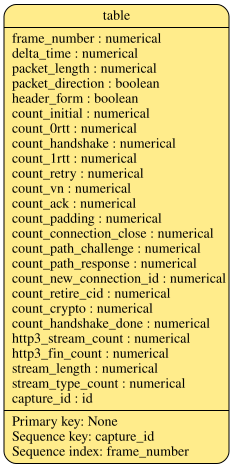

In [157]:
metadata.visualize()

In [159]:
data[binary_cols] = data[binary_cols].astype(bool)

In [162]:
from sdv.sequential import PARSynthesizer

synthesizer = PARSynthesizer(metadata, verbose=True)
synthesizer.fit(data)

synthetic_data = synthesizer.sample(num_sequences=100)

100%|██████████| 100/100 [01:07<00:00,  1.48it/s]


In [165]:
synthetic_data[synthetic_data['capture_id'] == 3159657]

,frame_number,delta_time,packet_length,packet_direction,header_form,count_initial,count_0rtt,count_handshake,count_1rtt,count_retry,...,count_path_response,count_new_connection_id,count_retire_cid,count_crypto,count_handshake_done,http3_stream_count,http3_fin_count,stream_length,stream_type_count,capture_id
0,1,0.000000,500,False,True,0,0,0,1,0,...,0,0,0,1,0,0,0,3,0,3159657
1,2,0.001020,500,True,True,0,0,0,1,0,...,0,0,0,0,0,0,0,12,0,3159657
2,3,0.000484,1092,False,False,0,0,0,0,0,...,0,0,0,0,0,0,0,4,0,3159657
3,4,0.000425,1150,False,True,0,0,1,0,0,...,0,0,0,0,0,0,0,3,0,3159657
4,5,0.001070,936,False,False,0,0,0,1,0,...,0,0,0,1,0,0,0,12,0,3159657
5,6,0.000374,1441,False,True,1,0,0,1,0,...,0,0,0,1,0,0,0,1,0,3159657
6,7,0.001536,700,True,True,0,0,1,1,0,...,0,0,0,1,0,0,0,2,0,3159657
7,8,0.002448,752,True,True,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,3159657
8,9,0.001311,430,True,True,0,0,0,1,0,...,0,0,0,1,0,0,0,5,0,3159657
9,10,0.001509,739,True,False,0,0,1,0,0,...,0,0,0,1,0,0,0,5,0,3159657
